<a href="https://colab.research.google.com/github/locbp-uzh/biopipelines/blob/main/ExamplePipelines/notebooks/compound_screening_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compound Library Screening

**BioPipelines example** — SAR screening of a compound library against a protein–DNA complex using Boltz2. Predicted affinities are merged with compound metadata and plotted by substituent group.

[![Documentation](https://img.shields.io/badge/docs-readthedocs-blue)](https://biopipelines.readthedocs.io/en/latest/)
[![Preprint](https://img.shields.io/badge/preprint-bioRxiv-B31B1B)](https://www.biorxiv.org/content/10.64898/2026.03.11.711024v1)

In [1]:
# Cell 1: Install BioPipelines and micromamba
!git clone https://github.com/locbp-uzh/biopipelines
%cd biopipelines
!pip install -e ".[all]"
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj -C /usr/local bin/micromamba
!micromamba create -f Environments/biopipelines.yaml -y

Cloning into 'biopipelines'...
remote: Enumerating objects: 7110, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 7110 (delta 192), reused 189 (delta 147), pack-reused 6829 (from 3)
Receiving objects: 100% (7110/7110), 14.68 MiB | 17.83 MiB/s, done.
Resolving deltas: 100% (5277/5277), done.
/content/biopipelines
Obtaining file:///content/biopipelines
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.1 MB/s eta 0:00:00
  Building editable for biopipelines (pyproject.toml) ... done
  Created wheel for biopipelines: filename=biopipelines-1.1.0-0.editabl

In [2]:
# Cell 2: Install tools
from biopipelines.pipeline import *
from biopipelines.boltz2 import Boltz2

with Pipeline(project="Setup", job="InstallTools"):
    Boltz2.install()


Running Boltz2_installation (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
=== Installing Boltz2 ===
conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache


Transaction

  Prefix: /root/.local/share/mamba/envs/Boltz2Env

  Updating specs:

   - python=3.11


  Package               Version  Build                 Channel           Size
───────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge     Cached
  + bzip2                 1.0.8  hda65f42_9            conda-forge     Cached
  + ca-certificates   2026.2.25  hbd8a1cb_0            

## Cell 3: Compound Screening Pipeline

Screens a ChemDraw compound library against the Trp repressor–DNA complex.
Affinities are merged with substituent metadata and visualised with a scatter plot.

  Sequence TrpR: MAQQSPYSAAMAEERHQEWLRFVDLLKNAY... (type: protein, length: 108)

Running Sequence (step 1)
=== Activating Environment ===
Requested: biopipelines
Environment: biopipelines
Location: /root/.local/share/mamba/envs/biopipelines
Python: /root/.local/share/mamba/envs/biopipelines/bin/python
Python version: Python 3.12.13
Creating sequence files for 1 sequences
IDs: TrpR
Output folder: /content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/001_Sequence
Creating sequence files for 1 sequences
Output folder: /content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/001_Sequence
Created CSV: /content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/001_Sequence/sequences.csv
Created FASTA: /content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/001_Sequence/sequences.fasta

=== SEQUENCE SUMMARY ===
Total sequences: 1
  TrpR: MAQQSPYSAAMAEERHQEWLRFVDLLKNAY... (protein, 108 residues)

Sequence files created successfully
Checking outputs and

StandardizedOutput({'plots': DataStream(name='plots', format='png', items=1, files=1, map_table=unset), 'tables': {'metadata': TableInfo(name='metadata', path='/content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/006_Plot/plot_metadata.csv', columns=['filename', 'type', 'title', 'x_column', 'y_column', 'data_sources'], count=1), 'predicted_affinity_by_r1_group': TableInfo(name='predicted_affinity_by_r1_group', path='/content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/006_Plot/predicted_affinity_by_r1_group.csv', columns=[], count=variable)}, 'output_folder': '/content/biopipelines/tests/TrpRepressor/CompoundLibraryScreen_001/006_Plot'})
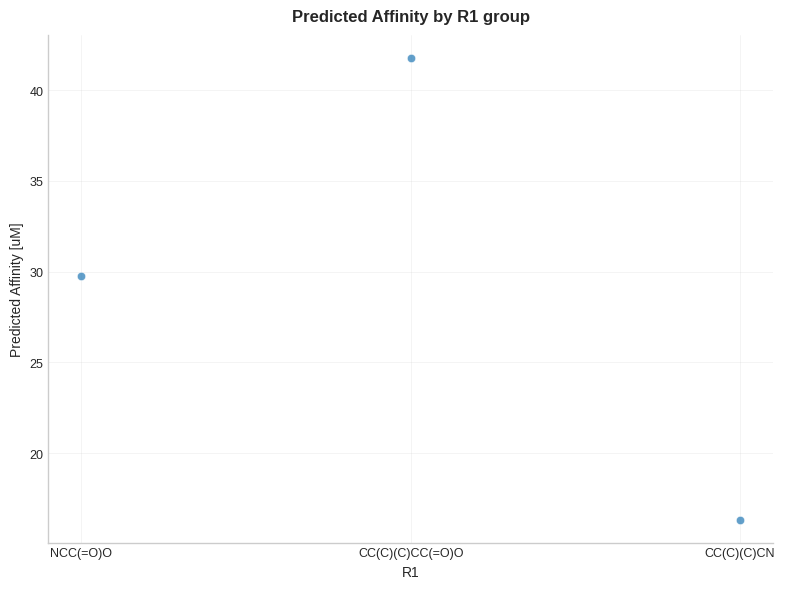

In [3]:
# Cell 3: Pipeline
from biopipelines.pipeline import *
from biopipelines.compound_library import CompoundLibrary
from biopipelines.boltz2 import Boltz2
from biopipelines.panda import Panda
from biopipelines.plot import Plot

with Pipeline(project="TrpRepressor", job="CompoundLibraryScreen"):
    TrpR = Sequence("MAQQSPYSAAMAEERHQEWLRFVDLLKNAYQNDLHLPLLNLMLTPDEREALGTRVRIVEELLRGEMSQRELKNELGAGIATITRGSNSLKAAPVELRQWLEEVLLKSD",
                    ids="TrpR")
    DNA = Sequence("TGTACTAGTTAACTAGTAC",
                   ids="dna")
    library = CompoundLibrary("./ExamplePipelines/compound_library_TrpR.cdxml")
    cofolded = Boltz2(proteins=Bundle(TrpR, TrpR),
                      dsDNA=DNA,
                      ligands=Each(library))
    merged = Panda(tables=[library.tables.compounds, cofolded.tables.affinity],
                   operations=[Panda.merge(),
                                Panda.calculate({"aff_uM": "10**affinity_pred_value"})])
    plots = Plot(Plot.Scatter(data=merged.tables.result,
                      x="R1",
                      y="aff_uM",
                      title="Predicted Affinity by R1 group",
                      xlabel="R1",
                      ylabel="Predicted Affinity [uM]"))
plots